# Reactor-Particle Coupling with Maxwell-Stefan Film Transfer

## Background

This notebook extends the reactor-particle coupling from L8 with an external multicomponent mass-transfer layer. The reactor gas concentration and the gas concentration at the particle boundary are separate unknowns. Their difference is not prescribed with a single scalar film coefficient per species; instead it follows the linearized Maxwell-Stefan film relation used in Exercise 7.2.

The model solves one monolithic residual for

```text
reactor gas concentration, particle-boundary gas concentration, particle concentration profile
```

at every axial cell. The example reaction is

$$
A \rightarrow B + C
$$

inside a spherical catalyst particle. The external film connects the gas phase to the particle surface.

## Governing Equations

The reactor gas balance for species $i$ is

$$
\frac{d}{dz}\left(v c_{g,i} - D_\mathrm{ax}\frac{dc_{g,i}}{dz}\right)
= \varepsilon_s \bar{R}_i,
$$

where $\bar{R}_i$ is the particle-volume averaged source term and $\varepsilon_s$ is the solid holdup.

The particle model is a spherical diffusion-reaction balance,

$$
\frac{1}{r^2}\frac{d}{dr}\left(r^2 D_{p,i}\frac{dc_{p,i}}{dr}\right) + R_i(c_p)=0,
$$

with symmetry at the particle center and a Dirichlet boundary value at the particle surface,

$$
c_{p,i}(R_p)=c_{b,i}.
$$

The particle source term is first order in $A$,

$$
R_i = \nu_i k c_{p,A}, \qquad \nu=(-1,1,1).
$$

The boundary concentration $c_b$ is coupled to the reactor concentration $c_g$ by a linearized Maxwell-Stefan film model. With $R_i^g=\varepsilon_s\bar{R}_i$ as the source per reactor volume and $k_{m,ij}a$ as pairwise volumetric film-transfer coefficients,

$$
c_{b,i}-c_{g,i}
=
\sum_{j\ne i}\frac{y_j R_i^g-y_i R_j^g}{k_{m,ij}a},
$$

where the mole fractions are evaluated from the film midpoint concentration,

$$
y_i=\frac{\tfrac12(c_{g,i}+c_{b,i})}{\sum_j \tfrac12(c_{g,j}+c_{b,j})}.
$$

For a consumed species this relation gives a lower boundary concentration than the reactor bulk. For produced species it gives a higher boundary concentration.

## Parameters and Assumptions

The numerical example is intentionally compact. It is meant to show the coupling pattern, not to represent a specific catalyst or gas mixture. The axial reactor has convection and a small amount of axial dispersion. The particles are spherical and radially resolved with grid refinement near the surface.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in (Path.cwd(), Path.cwd().parent):
    pymrm_src = candidate / "pymrm" / "src"
    if pymrm_src.exists() and str(pymrm_src) not in sys.path:
        sys.path.insert(0, str(pymrm_src))

from pymrm import (
    NumJac,
    construct_coefficient_matrix,
    construct_convflux_upwind,
    construct_div,
    construct_grad,
    newton,
    non_uniform_grid,
)

In [2]:
@dataclass
class ModelConfig:
    n_z: int = 40
    n_r: int = 14
    n_c: int = 3
    length: float = 1.0
    velocity: float = 0.30
    d_ax: float = 2.0e-5
    particle_radius: float = 1.0e-3
    particle_diffusivity: np.ndarray = field(default_factory=lambda: np.array([2.0e-6, 1.5e-6, 1.5e-6]))
    k_rxn: float = 3.0
    eps_s: float = 0.35
    inlet_concentration: np.ndarray = field(default_factory=lambda: np.array([1.0, 0.0, 0.0]))
    film_pair_coefficients: np.ndarray = field(
        default_factory=lambda: np.array(
            [
                [np.inf, 2.0e-3, 2.0e-3],
                [2.0e-3, np.inf, 4.0e-3],
                [2.0e-3, 4.0e-3, np.inf],
            ]
        )
    )
    tol: float = 1.0e-8
    maxfev: int = 20

    @property
    def external_area(self):
        return 3.0 * self.eps_s / self.particle_radius

    @property
    def kma(self):
        return self.film_pair_coefficients * self.external_area


cfg = ModelConfig()

pd.Series(
    {
        "axial cells": cfg.n_z,
        "particle radial cells": cfg.n_r,
        "reactor length [m]": cfg.length,
        "velocity [m/s]": cfg.velocity,
        "particle radius [mm]": 1e3 * cfg.particle_radius,
        "solid holdup [-]": cfg.eps_s,
        "external area [1/m]": cfg.external_area,
        "reaction rate constant [1/s]": cfg.k_rxn,
    },
    name="settings",
)

axial cells                       40.00
particle radial cells             14.00
reactor length [m]                 1.00
velocity [m/s]                     0.30
particle radius [mm]               1.00
solid holdup [-]                   0.35
external area [1/m]             1050.00
reaction rate constant [1/s]       3.00
Name: settings, dtype: float64

## PyMRM Implementation

The state array has shape `(n_z, n_r + 2, n_c)`:

- `u[:, 0, :]` is the reactor gas concentration $c_g$;
- `u[:, 1, :]` is the particle-boundary gas concentration $c_b$;
- `u[:, 2:, :]` is the resolved particle concentration $c_p(z,r,i)$.

This keeps the spatial coordinate first and the species index last. The constant reactor and particle transport operators are assembled once. The full coupled Jacobian is generated with `NumJac` using a sparse block-banded stencil: each axial cell may couple all local region/species variables, while the reactor transport also couples neighboring axial cells.

In [3]:
class ReactorParticleMaxwellStefanModel:
    species_labels = ("A", "B", "C")
    stoich = np.array([-1.0, 1.0, 1.0])

    def __init__(self, cfg: ModelConfig):
        self.cfg = cfg
        self.gas_shape = (cfg.n_z, cfg.n_c)
        self.boundary_shape = (cfg.n_z, 1, cfg.n_c)
        self.particle_shape = (cfg.n_z, cfg.n_r, cfg.n_c)
        self.shape = (cfg.n_z, cfg.n_r + 2, cfg.n_c)
        self._build_grids()
        self._build_operators()
        self.numjac = NumJac(self.shape, axes_diagonals=[0], axes_blocks=[1, 2])
        self.u0 = self.initial_state()
        self.u = self.u0.copy()

    def _build_grids(self):
        cfg = self.cfg
        self.z_f = np.linspace(0.0, cfg.length, cfg.n_z + 1)
        self.z_c = 0.5 * (self.z_f[:-1] + self.z_f[1:])
        self.r_f = non_uniform_grid(0.0, cfg.particle_radius, cfg.n_r + 1, 0.15 * cfg.particle_radius, 0.75)
        self.r_c = 0.5 * (self.r_f[:-1] + self.r_f[1:])
        self.volume_weights = np.diff(self.r_f**3) / self.r_f[-1] ** 3

    def _build_operators(self):
        cfg = self.cfg
        inlet_flux = cfg.velocity * cfg.inlet_concentration
        bc_axial = (
            {"a": cfg.d_ax, "b": cfg.velocity, "d": inlet_flux},
            {"a": 1.0, "b": 0.0, "d": 0.0},
        )
        grad_mat, grad_bc = construct_grad(self.gas_shape, self.z_f, self.z_c, bc=bc_axial, axis=0)
        conv_mat, conv_bc = construct_convflux_upwind(self.gas_shape, self.z_f, self.z_c, bc=bc_axial, v=cfg.velocity, axis=0)
        div_mat = construct_div(self.gas_shape, self.z_f, axis=0)
        d_ax_mat = construct_coefficient_matrix(cfg.d_ax, self.gas_shape, axis=0)
        self.gas_transport_mat = div_mat @ (conv_mat - d_ax_mat @ grad_mat)
        self.gas_transport_const = div_mat @ (conv_bc - d_ax_mat @ grad_bc)

        bc_particle = (
            {"a": 1.0, "b": 0.0, "d": 0.0},
            {"a": 0.0, "b": 1.0, "d": 1.0},
        )
        grad_p_mat, _, grad_p_bc = construct_grad(
            self.particle_shape,
            self.r_f,
            self.r_c,
            bc=bc_particle,
            axis=1,
            shapes_d=(None, self.boundary_shape),
        )
        div_p_mat = construct_div(self.particle_shape, self.r_f, nu=2, axis=1)
        d_p = cfg.particle_diffusivity.reshape(1, 1, cfg.n_c)
        d_p_mat = construct_coefficient_matrix(d_p, self.particle_shape, axis=1)
        self.particle_diffusion_mat = div_p_mat @ (-d_p_mat @ grad_p_mat)
        self.particle_boundary_mat = div_p_mat @ (-d_p_mat @ grad_p_bc)

    def initial_state(self):
        u = np.zeros(self.shape)
        u[:, :, :] = self.cfg.inlet_concentration.reshape(1, 1, self.cfg.n_c)
        return u

    def split_state(self, u):
        u = u.reshape(self.shape)
        return u[:, 0, :], u[:, 1, :], u[:, 2:, :]

    def particle_source(self, c_p):
        rate = self.cfg.k_rxn * c_p[..., 0]
        return self.stoich.reshape(1, 1, self.cfg.n_c) * rate[..., None]

    def particle_average_source(self, c_p):
        source = self.particle_source(c_p)
        return np.sum(source * self.volume_weights.reshape(1, -1, 1), axis=1)

    def maxwell_stefan_film_residual(self, c_g, c_b, source_reactor):
        c_mid = 0.5 * (c_g + c_b)
        y_mid = c_mid / np.maximum(np.sum(c_mid, axis=-1, keepdims=True), 1.0e-30)
        correction = np.zeros_like(c_g)
        for i in range(self.cfg.n_c):
            for j in range(self.cfg.n_c):
                if i != j:
                    correction[:, i] += (
                        y_mid[:, j] * source_reactor[:, i]
                        - y_mid[:, i] * source_reactor[:, j]
                    ) / self.cfg.kma[i, j]
        return c_b - c_g - correction

    def residual_values(self, u):
        c_g, c_b, c_p = self.split_state(u)
        source_particle = self.particle_source(c_p)
        source_reactor = self.cfg.eps_s * self.particle_average_source(c_p)

        residual = np.zeros_like(u)
        residual[:, 0, :] = (
            self.gas_transport_const
            + self.gas_transport_mat @ c_g.reshape(-1, 1)
        ).reshape(self.gas_shape) - source_reactor
        residual[:, 1, :] = self.maxwell_stefan_film_residual(c_g, c_b, source_reactor)
        residual[:, 2:, :] = (
            self.particle_diffusion_mat @ c_p.reshape(-1, 1)
            + self.particle_boundary_mat @ c_b[:, None, :].reshape(-1, 1)
        ).reshape(self.particle_shape) - source_particle
        return residual

    def residual(self, u):
        u = u.reshape(self.shape)
        residual = self.residual_values(u)
        residual, jac = self.numjac(self.residual_values, u, f_value=residual)
        return residual.ravel(), jac

    def solve(self):
        result = newton(self.residual, self.u, tol=self.cfg.tol, maxfev=self.cfg.maxfev, solver="spsolve")
        self.u = result.x.reshape(self.shape)
        self.result = result
        return result

    def fields(self):
        return self.split_state(self.u)

    def effectiveness_profile(self):
        _c_g, c_b, c_p = self.fields()
        rate_average = self.particle_average_source(c_p)[:, 0] / self.stoich[0]
        rate_surface = self.cfg.k_rxn * c_b[:, 0]
        return rate_average / np.maximum(rate_surface, 1.0e-30)

In [4]:
model = ReactorParticleMaxwellStefanModel(cfg)
result = model.solve()
c_g, c_b, c_p = model.fields()
source_reactor = cfg.eps_s * model.particle_average_source(c_p)

pd.Series(
    {
        "success": result.success,
        "message": result.message,
        "Newton iterations": result.nit,
        "final residual norm": np.linalg.norm(result.fun, ord=np.inf),
        "minimum concentration [mol/m3]": np.min(model.u),
        "outlet A conversion": 1.0 - c_g[-1, 0] / c_g[0, 0],
        "outlet gas c_A [mol/m3]": c_g[-1, 0],
        "outlet boundary c_A [mol/m3]": c_b[-1, 0],
    },
    name="solve summary",
)

success                                True
message                           Converged
Newton iterations                         5
final residual norm                     0.0
minimum concentration [mol/m3]      0.04295
outlet A conversion                0.855764
outlet gas c_A [mol/m3]            0.138041
outlet boundary c_A [mol/m3]       0.093007
Name: solve summary, dtype: object

## Results

The gas and boundary concentrations separate because the film transfer is finite. The boundary concentration of reactant $A$ is below the reactor gas concentration, while the products are enriched at the particle boundary.

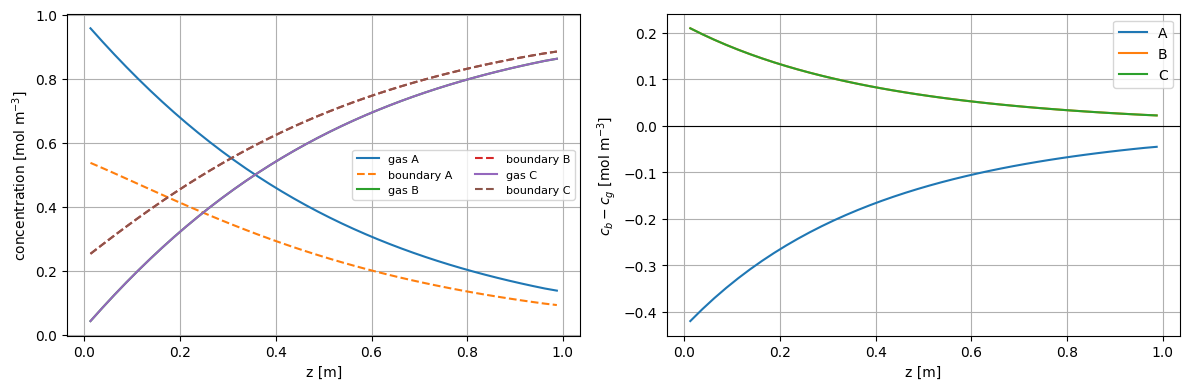

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for i, label in enumerate(model.species_labels):
    axes[0].plot(model.z_c, c_g[:, i], label=f"gas {label}")
    axes[0].plot(model.z_c, c_b[:, i], "--", label=f"boundary {label}")
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("concentration [mol m$^{-3}$]")
axes[0].legend(ncol=2, fontsize=8)
axes[0].grid(True)

for i, label in enumerate(model.species_labels):
    axes[1].plot(model.z_c, c_b[:, i] - c_g[:, i], label=label)
axes[1].axhline(0.0, color="k", linewidth=0.8)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel("$c_b-c_g$ [mol m$^{-3}$]")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

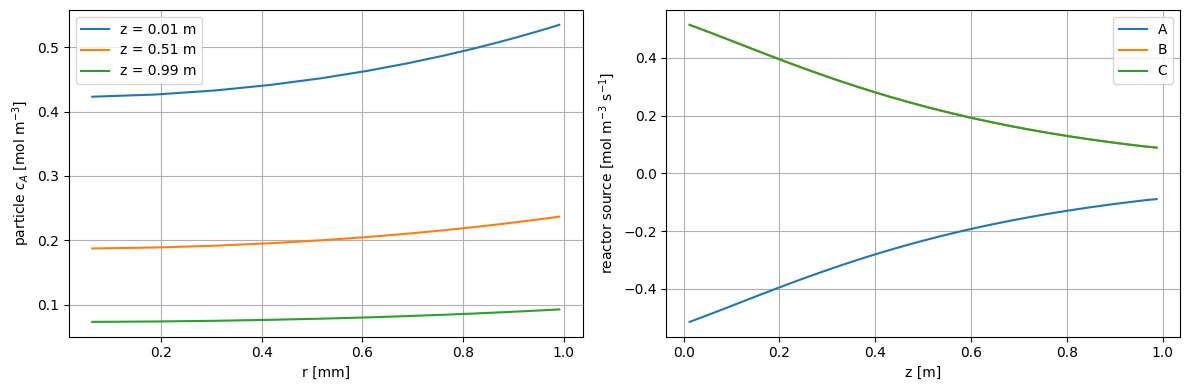

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
positions = [0, cfg.n_z // 2, cfg.n_z - 1]
colors = ["tab:blue", "tab:orange", "tab:green"]
for idx, color in zip(positions, colors):
    axes[0].plot(1e3 * model.r_c, c_p[idx, :, 0], color=color, label=f"z = {model.z_c[idx]:.2f} m")
axes[0].set_xlabel("r [mm]")
axes[0].set_ylabel("particle $c_A$ [mol m$^{-3}$]")
axes[0].legend()
axes[0].grid(True)

for i, label in enumerate(model.species_labels):
    axes[1].plot(model.z_c, source_reactor[:, i], label=label)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel("reactor source [mol m$^{-3}$ s$^{-1}$]")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

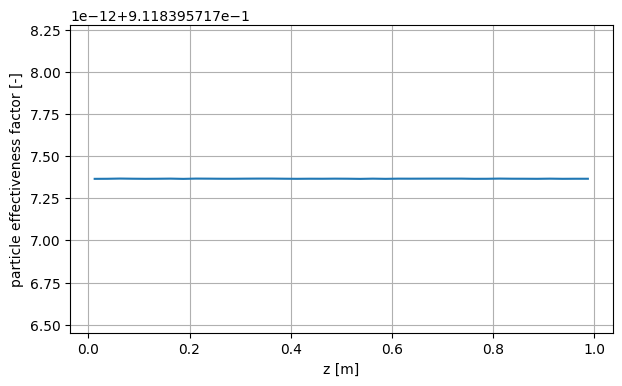

In [7]:
effectiveness = model.effectiveness_profile()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(model.z_c, effectiveness)
ax.set_xlabel("z [m]")
ax.set_ylabel("particle effectiveness factor [-]")
ax.grid(True)
plt.show()

## Validation

The checks below are numerical consistency checks for the coupled residual. The residual norm verifies the monolithic solve. The Maxwell-Stefan row check recomputes only the film equation. The signs of the film concentration differences should also be physically consistent: reactant $A$ is consumed in the particle, so $c_{b,A}<c_{g,A}$, while products are generated and tend to have $c_{b,i}>c_{g,i}$.

In [8]:
film_residual = model.maxwell_stefan_film_residual(c_g, c_b, source_reactor)
particle_residual = model.residual_values(model.u)[:, 2:, :]

pd.Series(
    {
        "monolithic residual norm": np.linalg.norm(result.fun, ord=np.inf),
        "film residual norm": np.linalg.norm(film_residual.ravel(), ord=np.inf),
        "particle residual norm": np.linalg.norm(particle_residual.ravel(), ord=np.inf),
        "min(c_b,A - c_g,A) [mol/m3]": np.min(c_b[:, 0] - c_g[:, 0]),
        "max(c_b,B - c_g,B) [mol/m3]": np.max(c_b[:, 1] - c_g[:, 1]),
        "max(c_b,C - c_g,C) [mol/m3]": np.max(c_b[:, 2] - c_g[:, 2]),
    },
    name="checks",
)

monolithic residual norm       3.137490e-12
film residual norm             1.387779e-16
particle residual norm         3.204326e-12
min(c_b,A - c_g,A) [mol/m3]   -4.201240e-01
max(c_b,B - c_g,B) [mol/m3]    2.100620e-01
max(c_b,C - c_g,C) [mol/m3]    2.100620e-01
Name: checks, dtype: float64

## Discussion

The extra boundary concentration block is the main modeling change compared with direct reactor-particle coupling. The reactor no longer supplies the particle-surface concentration directly. Instead, the reactor concentration $c_g$, boundary concentration $c_b$, and particle profile $c_p$ are solved together.

The linearized Maxwell-Stefan film equation is algebraic, but it is strongly coupled to the particle because the apparent source term comes from the resolved particle profile. The resulting block structure is useful for lecture purposes:

- the reactor transport row contains axial convection-dispersion and the particle source;
- the film row contains the Maxwell-Stefan relation between $c_g$, $c_b$, and the apparent source;
- the particle rows contain radial diffusion-reaction with $c_b$ as the surface boundary value.

For very large pairwise film coefficients, the correction term becomes small and $c_b\approx c_g$. For smaller coefficients, the boundary concentration difference becomes the external mass-transfer driving force. This is the point where a simple scalar film coefficient and a multicomponent Maxwell-Stefan film model start to behave differently.